In [46]:
import json
import glob
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

def load_scores(file_path):
    steps = []
    scores = []
    with open(file_path, 'r') as f:
        for line in f:
            data = json.loads(line)
            steps.append(data['step'])
            scores.append(data['episode/score'])
    return np.array(steps), np.array(scores)

def smooth(y, window_size=50):
    if len(y) < window_size:
        return y
    return np.convolve(y, np.ones(window_size)/window_size, mode='valid')

def plot_agent_scores(jsonl_paths, labels=None, window_size=50):
    color_list = ['tab:green', 'tab:pink', 'tab:grey', 'tab:blue']
    plt.figure(figsize=(4, 3))

    for i, path in enumerate(jsonl_paths):
        steps, scores = load_scores(path)

        # Sort by steps in case data is unordered
        sorted_indices = np.argsort(steps)
        steps, scores = steps[sorted_indices], scores[sorted_indices]

        # Apply smoothing
        smoothed_scores = smooth(scores, window_size)
        smoothed_steps = smooth(steps, window_size)

        # Compute std for shading
        #std = np.std(scores)
        std=0

        label = labels[i] if labels else f"Agent {i+1}"
        plt.plot(smoothed_steps, smoothed_scores, label=label, c=color_list[i], linewidth=5)
        #plt.fill_between(smoothed_steps, smoothed_scores - std, smoothed_scores + std, alpha=0.2)

    plt.xlabel("Steps")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [42]:
plt.rcParams.update({'font.size': 16})

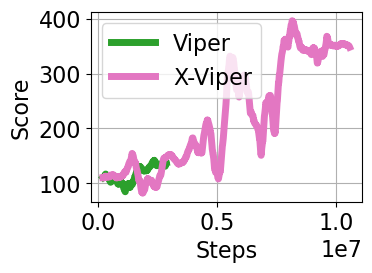

In [33]:
jsonl_paths = ["/home/zyang/XViper/logdir/dmc_cartpole_swingup/2/scores.jsonl", "/home/zyang/XViper/logdir/dmc_cartpole_swingup/30/scores.jsonl"]
plot_agent_scores(jsonl_paths, labels=["Viper", "X-Viper"])

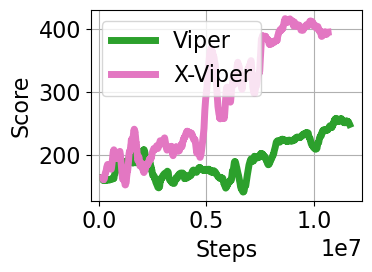

In [35]:
jsonl_paths = ["/home/zyang/XViper/logdir/dmc_cartpole_balance/2/scores.jsonl", "/home/zyang/XViper/logdir/dmc_cartpole_balance/30/scores.jsonl"]
plot_agent_scores(jsonl_paths, labels=["Viper", "X-Viper"])

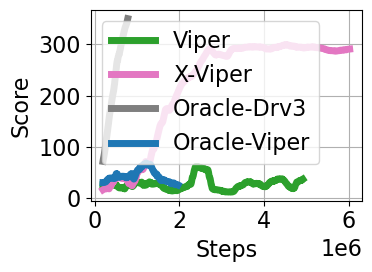

In [47]:
jsonl_paths = ["/home/zyang/XViper/logdir/dmc_cheetah_run/2/scores.jsonl", "/home/zyang/XViper/logdir/dmc_cheetah_run/20/scores.jsonl", "/home/zyang/XViper/logdir/dmc_cheetah_run/4/scores.jsonl", "/home/zyang/XViper/logdir/dmc_cheetah_run/3/scores.jsonl"]
plot_agent_scores(jsonl_paths, labels=["Viper", "X-Viper", "Oracle-Drv3", "Oracle-Viper"])

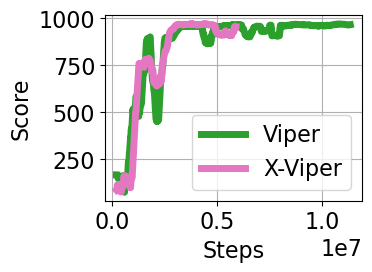

In [45]:
jsonl_paths = ["/home/zyang/XViper/logdir/dmc_cup_catch/2/scores.jsonl", "/home/zyang/XViper/logdir/dmc_cup_catch/20/scores.jsonl"]
plot_agent_scores(jsonl_paths, labels=["Viper", "X-Viper"])